# **Spatial Patterns of Diversity - ACUS Zamora Chinchipe**

Author: Daning Montaño - Ocampo

Se fusiona la base de datos de BNDB y GBIF para su posterior limpieza de datos basado en filtros aplicados a metadatos, nivel taxonómico y validación del nombre científico basado en GBIF.

# **1. Packages and libraries**

In [133]:
suppressMessages({
library(dplyr)
library(readr)
library(bdc) ## data cleaning
library(lubridate)
library(stringr)
library(doParallel)
library(CoordinateCleaner)
library(sf)
library(purrr)
library(tibble)
library(rgbif)})

# **2. Cut data based on ACUS**

## 2.1 Load raw data

In [134]:
gbfi = read_delim("../../../DATOS/Datasets/Biodiversidad/occurrence_gbif.txt",delim = "\t")

Rows: 706176 Columns: 230
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (127): accessRights, bibliographicCitation, language, license, publisher, references, rightsHolder, type, institutionID, collectionID, datasetI...
dbl   (26): gbifID, individualCount, organismQuantity, startDayOfYear, endDayOfYear, year, month, day, sampleSizeValue, decimalLatitude, decimalLong...
lgl   (71): dataGeneralizations, caste, pathway, associatedOccurrences, associatedReferences, associatedSequences, organismName, organismScope, asso...
dttm   (5): modified, dateIdentified, lastInterpreted, lastParsed, lastCrawled
date   (1): georeferencedDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat) 


In [135]:
bndb = read_csv("../../../DATOS/Datasets/Biodiversidad/occurrences_bndb.csv")


Rows: 60853 Columns: 92
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (63): institutionCode, collectionCode, ownerInstitutionCode, collectionID, basisOfRecord, occurrenceID, catalogNumber, otherCatalogNumbers, hig...
dbl  (14): id, taxonID, year, month, day, startDayOfYear, endDayOfYear, individualCount, decimalLatitude, decimalLongitude, coordinateUncertaintyInM...
lgl  (14): subgenus, eventID, informationWithheld, dataGeneralizations, associatedSequences, associatedTaxa, locationID, islandGroup, island, georef...
dttm  (1): modified

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat) 


In [136]:
ruta <- "../../../DATOS/Datasets/Biodiversidad/bioweb"

# listar archivos que empiezan con bioweb
archivos <- list.files(
  path = ruta,
  pattern = "^bioweb.*\\.txt$",
  full.names = TRUE
)

leer_bioweb <- function(archivo) {

  # leer líneas respetando codificación original
  lineas <- readLines(archivo, warn = FALSE, encoding = "Latin1")
  lineas <- iconv(lineas, from = "Latin1", to = "UTF-8", sub = "")
  
  # leer tabla forzando todas las columnas como texto
  df <- read.delim(
    text = paste(lineas, collapse = "\n"),
    sep = "\t",
    header = TRUE,
    quote = "",
    fill = TRUE,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    row.names = NULL,
    colClasses = "character"
  )
  
  df$archivo_origen <- basename(archivo)
  df
}

# leer todos los archivos y unirlos
bioweb <- map(archivos, leer_bioweb) |>
  bind_rows()

# convertir columnas numéricas necesarias
bioweb <- bioweb |>
  mutate(
    latitude   = suppressWarnings(as.numeric(latitude)),
    longitude  = suppressWarnings(as.numeric(longitude)),
    altitudMin = suppressWarnings(as.numeric(altitudMin)),
    altitudMax = suppressWarnings(as.numeric(altitudMax)),
    grupo_fuente = str_remove(archivo_origen, "^bioweb_|\\.txt$")
  )

## 2.2. Load Grids - ACUS

In [137]:
grids_1km = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp") |> 
  st_transform(4326) ## transform coordinates

Reading layer `grid_zamora_ch_buffer_1km' from data source `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S


## 2.3. Extract only ID per dataset and Coordinates

In [138]:
gbfi_coordinates = gbfi|> select(gbifID, decimalLatitude, decimalLongitude)|> ## select only ids and coordinates
  filter(!is.na(decimalLatitude))|> # filter NA coordinates
  filter(!is.na(decimalLongitude))|># filter NA coordinates
  st_as_sf(coords = c("decimalLongitude", "decimalLatitude"), crs = 4326) |> # create sf object
  st_transform(4326)|>  # transform to 4326 system
  st_filter(grids_1km, .predicate = st_within) # cut based on acus grids



bndb_coordinates = bndb|> select(id, decimalLatitude, decimalLongitude)|>
  filter(!is.na(decimalLatitude))|>
  filter(!is.na(decimalLongitude))|>
  st_as_sf(coords = c("decimalLongitude", "decimalLatitude"), crs = 4326) |>
  st_transform(4326)|>
  st_filter(grids_1km, .predicate = st_within)



bioweb_coordinates = bioweb|> select(row.names, latitude, longitude)|>
  filter(!is.na(latitude))|>
  filter(!is.na(longitude))|>
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326) |>
  st_transform(4326)|>
  st_filter(grids_1km, .predicate = st_within)

## 2.4. Select ocurrences based on id selected

In [139]:
gbfi_selected = gbfi %>%
  filter(gbifID %in% gbfi_coordinates$gbifID) ## select based on id

bndb_selected = bndb %>%
  filter(id %in% bndb_coordinates$id) ## select based on id

bioweb_selected = bioweb %>%
  filter(row.names %in% bioweb_coordinates$row.names) ## select based on id

## 2.5. Expor pre-processed data

In [140]:

clean_names <- function(df){
  names(df) <- names(df) |>
    str_trim() |>               # elimina espacios
    str_replace_all(" ", "") |> # elimina espacios internos
    str_replace_all("\\.", "")  # elimina puntos añadidos por R
  df
}

gbfi_selected  <- clean_names(gbfi_selected)
bndb_selected  <- clean_names(bndb_selected)
bioweb_selected <- clean_names(bioweb_selected)

write_csv(
  gbfi_selected,
  "../../../DATOS/Datasets/Biodiversidad/gbif_selected.csv",
  na = ""
)

write_csv(
  bndb_selected,
  "../../../DATOS/Datasets/Biodiversidad/bndb_selected.csv",
  na = ""
)

write_csv(
  bioweb_selected,
  "../../../DATOS/Datasets/Biodiversidad/bioweb_selected.csv",
  na = ""
)

## **2.6 Load and homogenize Data**

We used data from:
- Global Biodiversity Information Facility (GBIF)
- PUCE - museum
- Base nacional de datos de biodiversidad (BNDB)

To homogenize and clean the data from different databases we used "bdc" package. 

Metadata file contains the information of the different columns names of the databaases and assing a unique name in a single database.

In [141]:
metadata <- tibble::tibble(
  datasetName = c("GBIF", "BNDB"),
  fileName = c(
    "../../../DATOS/Datasets/Biodiversidad/gbif_selected.csv",
    "../../../DATOS/Datasets/Biodiversidad/bndb_selected.csv"
  ),
  scientificName = c("scientificName", "scientificName"),
  decimalLatitude = c("decimalLatitude", "decimalLatitude"),
  decimalLongitude = c("decimalLongitude", "decimalLongitude"),
  gbifID = c("gbifID", "id"),
  occurrenceID = c("occurrenceID", "occurrenceID"),
  collectionID = c("collectionID", "collectionID"),
  institutionCode = c("institutionCode", "institutionCode"),
  collectionCode = c("collectionCode", "collectionCode"),
  ownerInstitutionCode = c("ownerInstitutionCode", "ownerInstitutionCode"),
  basisOfRecord = c("basisOfRecord", "basisOfRecord"),
  individualCount = c("individualCount", "individualCount"),
  eventDate = c("eventDate", "eventDate"),
  year = c("year", "year"),
  coordinateUncertaintyInMeters = c("coordinateUncertaintyInMeters", "coordinateUncertaintyInMeters"),
  higherClassification = c("higherClassification", "higherClassification"),
  kingdom = c("kingdom", "kingdom"),
  phylum = c("phylum", "phylum"),
  class = c("class", "class"),
  order = c("order", "order"),
  genus = c("genus", "genus"),
  specificEpithet = c("specificEpithet", "specificEpithet"),
  taxonRank = c("taxonRank", "taxonRank")
)

Load the data using metadata file parameters

In [142]:
database<-
  bdc_standardize_datasets(metadata = metadata,
                           format = "csv",
                           overwrite = T,
                           save_database = F)


print(head(database))

Standardizing GBIF file
Standardizing BNDB file


Warning messages:
1: One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat) 
2: One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat) 


# A tibble: 6 × 23
  database_id scientificName       decimalLatitude decimalLongitude gbifID occurrenceID collectionID institutionCode collectionCode ownerInstitutionCode
  <chr>       <chr>                <chr>           <chr>            <chr>  <chr>        <chr>        <chr>           <chr>          <chr>               
1 BNDB_1      Passiflora           -4.7375286112   -79.3564826414   16478… https://www… 5b4b914c-7c… iNaturalist     iNaturalistEC  INABIO              
2 BNDB_2      Microchloa kunthii   -4.5167         -79.4167         88059  453fb57d-f7… 56f4cb2b-3d… INABIOEC        QCNE           INABIO              
3 BNDB_3      Oritrophium yacurie… -4.65           -79.3            8675   f39fed7e-0c… 56f4cb2b-3d… INABIOEC        QCNE           INABIO              
4 BNDB_4      Nectandra reticulata -4.6667         -79.3            15819  8a4a5e7e-63… 56f4cb2b-3d… INABIOEC        QCNE           INABIO              
5 BNDB_5      Condaminea corymbosa -4.6667         -79.3       

Create a new column with the name of the data source

In [143]:

database$database_name =sub("_.*", "", database$database_id)
unique(database$database_name)

[1] "BNDB" "GBIF"

Inicial dimension of the dataset

In [144]:
dimension = database %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           59617  8.41
2 GBIF          649468 91.6 

In [145]:
len_0 = sum(dimension$n)
cat("Dataset size:", len_0)

Dataset size: 709085

# **3. Cleaning**

## 3.1. Clean repeated ocurrendIDs

In [146]:
database_1 = database %>%
  distinct(occurrenceID, .keep_all = TRUE)
dimension_1= database_1 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_1

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           35903  5.35
2 GBIF          634995 94.6 

In [147]:
len_1= sum(dimension_1$n)
cat("Dataset size:", len_1)

Dataset size: 670898

## 3.2. Select only species level data

We only keeped data from Species level. We filter using all the ways of species could be written.
NA values ara manteined despite the fact that they comes from BNDN data, wich does not have Taxon rank information, for this we delete using NA in taxon Name

In [148]:
unique(database_1$taxonRank)

 [1] "Genus"      "Species"    "Family"     NA           "Tribe"      "Subspecies" "Morph"      "Phylum"     "Subgenus"   "GENUS"      "SPECIES"   
[12] "FAMILY"     "UNRANKED"   "SUBSPECIES" "CLASS"      "ORDER"      "VARIETY"    "KINGDOM"    "PHYLUM"     "FORM"      

In [149]:
database_2 = database_1 %>%
  filter(taxonRank %in% c( "Species","SPECIES" ,  "SUBSPECIES", "Subspecies", "species", "subspecies", "Species group", "Subspec"))  %>%
  filter(!is.na(scientificName ))
dimension_2 = database_2 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_2

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           14198  2.44
2 GBIF          568424 97.6 

In [150]:

len_2= sum(dimension_2$n)
cat("Dataset size:", len_2)

Dataset size: 582622

## 3.4 Filter date (1970 - 2024)

Exploration of year variable

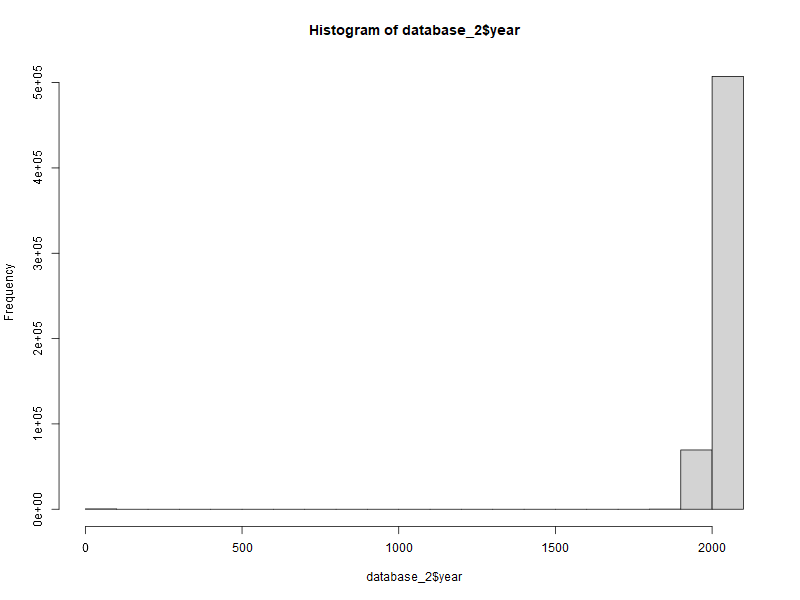

In [151]:
database_2$year = as.numeric(database_2$year)
hist(database_2$year)


Filtering 1970 - 2024

In [152]:
cat( "Min year", min(na.omit(database_2$year)))

Min year 0

In [153]:
cat( "Max year", max(na.omit(database_2$year)))

Max year 2026

In [154]:
database_3 = database_2 %>%
  filter(!is.na(year)) %>%
  filter(year >= 1970) %>%
  filter(year <= 2025) 
dimension_3 = database_3 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_3

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13394  2.33
2 GBIF          560740 97.7 

In [155]:

len_3= sum(dimension_3$n)
cat("Dataset size:", len_3)

Dataset size: 574134

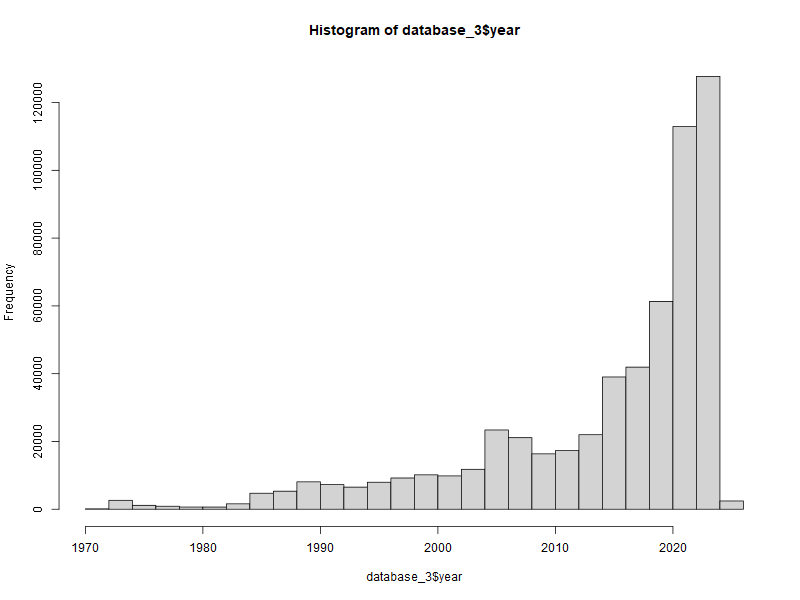

In [156]:
hist(database_3$year)

## 3.3. Delete Empy coordinates

In [157]:
database_4 = database_3 %>% 
  filter(!is.na(decimalLatitude)) %>% 
  filter(!is.na(decimalLongitude)) 
dimension_4 = database_4 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_4

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13394  2.33
2 GBIF          560740 97.7 

In [158]:
len_4= sum(dimension_4$n)
cat("Dataset size:", len_4)

Dataset size: 574134

## 3.5. Filter coordinates out of range

The funtions from bdc packages add flags to the data frame to indicate if there is a problem with the data

In [159]:
database_5 = bdc_coordinates_outOfRange(data = database_4, 
lat = "decimalLatitude",
lon = "decimalLongitude") %>%
  filter(.coordinates_outOfRange == TRUE)

dimension_5 = database_5 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_5


bdc_coordinates_outOfRange:
Flagged 0 records.
One column was added to the database.



# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13394  2.33
2 GBIF          560740 97.7 

In [160]:
len_5= sum(dimension_5$n)
cat("Dataset size:", len_5)

Dataset size: 574134

## 3.6. Filter coordinate Uncertainty

We only keep records with an accuracy of less than 10 km. If the value is NA, it is retained and other types of spatial filters are applied in the following steps.

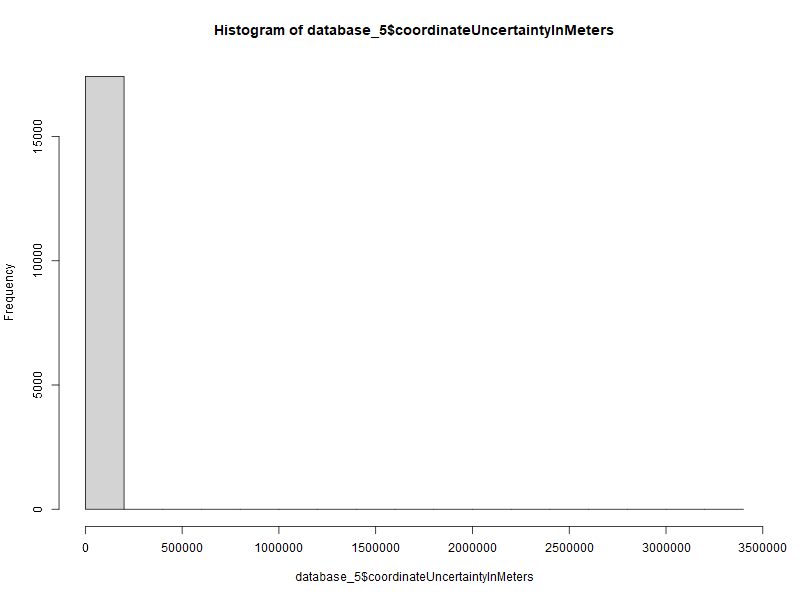

In [161]:
database_5$coordinateUncertaintyInMeters = as.numeric(database_5$coordinateUncertaintyInMeters)
hist(database_5$coordinateUncertaintyInMeters)

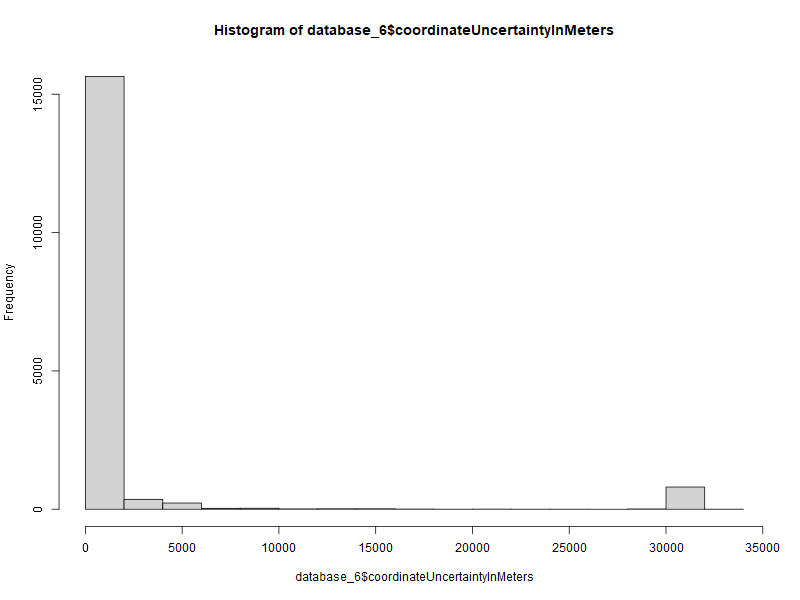

In [162]:
# Crear un nuevo dataframe filtrado a partir de database_5
database_6 <- database_5 |>
  
  # Filtrar registros según la incertidumbre de las coordenadas
  dplyr::filter(
    
    # Aplicar una condición diferente dependiendo de la fuente de datos
    dplyr::case_when(
      
      # Si el registro proviene de iNaturalist
      # se permiten valores de incertidumbre hasta 35 km
      institutionCode == "iNaturalist" ~ 
## en este caso inat cuando hay especies en peligro o bajo criterio de onservación obscure sus coordenadas (aprox 35 mil metros), 
## solo estas se mantienen porque tienen especies que pueden ser relevantes para el reporte, pero no el análisis
        coordinateUncertaintyInMeters <= 35000 | is.na(coordinateUncertaintyInMeters),
      
      # Para todos los demás repositorios
      # se usa un filtro de 5 km
      TRUE ~ 
        coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters)
    )
  )

# Visualizar la distribución de la incertidumbre espacial
# después del filtrado aplicado
hist(database_6$coordinateUncertaintyInMeters)


In [163]:
dimension_6 = database_6 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_6

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13392  2.33
2 GBIF          560495 97.7 

In [164]:
len_6= sum(dimension_6$n)
cat("Dataset size:", len_6)

Dataset size: 573887

database_6

## 3.7. Classify only Species and uncertainties

In [165]:
identify_uncert <- function(name) {
  uncer_terms <- FALSE
  infraesp_names <- FALSE
  generic_only <- FALSE
  
  # Incertidumbre ("cf.", "aff.", "?", "nr.", "indet.", "undet")
  if (grepl("\\b(cf\\.?|aff\\.?|nr\\.?|indet\\.?|undet\\.?|\\?)\\b", name, ignore.case = TRUE)) {
    uncer_terms <- TRUE
  }
  

  
  # Género sin especie ("sp.", "spp.")
 # if (grepl("\\b(sp\\.|spp\\.)\\b", name, ignore.case = TRUE)) {
  #  generic_only <- TRUE
  #}
  
  return(list(
    name = name,
    uncer_terms = uncer_terms

    #generic_only = generic_only
  ))
}


In [166]:
sp_names = unique(database_6$scientificName)
uncertain_results <- map(sp_names , identify_uncert)
uncertain_results_df <- do.call(rbind, lapply(uncertain_results, as.data.frame))
uncertain_results_df

                             name uncer_terms
1              Microchloa kunthii       FALSE
2          Oritrophium yacuriense       FALSE
3            Nectandra reticulata       FALSE
4            Condaminea corymbosa       FALSE
5        Ladenbergia oblongifolia       FALSE
6             Psychotria subfusca       FALSE
7            Calliandra trinervia       FALSE
8                 Monnina confusa       FALSE
9            Weinmannia spruceana       FALSE
10            Huperzia brevifolia       FALSE
11               Blechnum auratum       FALSE
12        Schefflera planchoniana       FALSE
13             Valeriana protenta       FALSE
14            Valeriana tomentosa       FALSE
15             Sorocea trophoides       FALSE
16             Rubus megalococcus       FALSE
17                 Rubus loxensis       FALSE
18             Palicourea demissa       FALSE
19            Agrostis tolucensis       FALSE
20        Calamagrostis rupestris       FALSE
21         Aechmea wuelfinghoffii 

In [167]:
database_7 = database_6 %>%
  left_join(uncertain_results_df, by = c("scientificName" = "name"))%>%
  filter(uncer_terms == FALSE)# %>%
  #filter(generic_only == FALSE)
dimension_7 = database_7 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_7

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13392  2.33
2 GBIF          560495 97.7 

In [168]:
len_7= sum(dimension_7$n)
cat("Dataset size:", len_7)

Dataset size: 573887

## 3.8. Cleaning names

In [169]:
database_7$ scientificName = paste(database_7$genus,database_7$specificEpithet, sep = " " )

sp_names = unique(database_7$scientificName)
sp_names_clean = bdc_clean_names(
  sp_names,
  save_outputs = FALSE
)


>> Family names prepended to scientific names were flagged and removed from 1 records.
>> Terms denoting taxonomic uncertainty were flagged and removed from 0 records.
>> Other issues, capitalizing the first letter of the generic name, replacing empty names by NA, and removing extra spaces, were flagged and corrected or removed from 0 records.
>> Infraspecific terms were flagged and removed from 0 records.



0 → Not interpretable (name could not be parsed).

1 → No problems detected (clean, valid name).

2 → Minor issues (uncertainty terms or small variants, but cleaned successfully).

3 → Moderate issues (complex authorship, ambiguous notation, partially resolved).

4 → Serious problems (multiple inconsistencies, requires manual review).

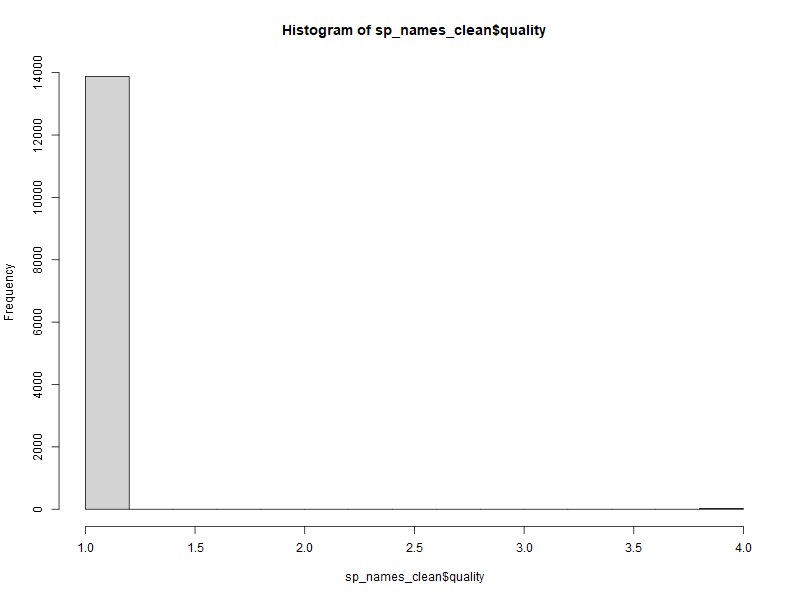

In [170]:
hist(sp_names_clean$quality)

Join clean scientific names with dataframe with all date

In [171]:
database_8 = database_7 %>%
  left_join(sp_names_clean, by = c("scientificName" = "scientificName"))%>%
  filter(quality %in% c(1, 2))

dimension_8 = database_8 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_8

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           13389  2.33
2 GBIF          560277 97.7 

In [172]:
len_8= sum(dimension_8$n)
cat("Dataset size:", len_8)

Dataset size: 573666

## 3.9. Coordinate precision

1 decimal is aprox 11 km of precision 

In [173]:
database_9 <-
  bdc_coordinates_precision(
    data = database_8,
    lon = "decimalLongitude",
    lat = "decimalLatitude",
    ndec = c(2) # number of decimals to be tested
  )%>%
  filter( .rou == TRUE)
dimension_9 = database_9 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

print(dimension_9)


bdc_coordinates_precision:
Flagged 11622 records
One column was added to the database.

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB           11785  2.10
2 GBIF          550259 97.9 


In [174]:
len_9= sum(dimension_9$n)
cat("Dataset size:", len_9)

Dataset size: 562044

## 3.10. Cooordinate cleaner

Create sci name using genus and specificEpithet

We filtered the dataset to keep only records that passed the tests for capitals (.cap), centroids (.cen), and outliers (.otl).

- cap → removes records with capitals that are not the main capital of the country.

- cen → removes records near administrative centroids (country or province centroids assigned by default).

- otl → removes geographic outliers that are far from the main distribution of the species.

This ensures that only records with reliable geographic positions remain, reducing the risk of biased results in downstream analyses.

In [175]:
database_9$decimalLatitude = as.numeric(database_9$decimalLatitude)
database_9$decimalLongitude = as.numeric(database_9$decimalLongitude)
database_10 <- CoordinateCleaner::clean_coordinates(
  x       = database_9,
  lon     = "decimalLongitude",
  lat     = "decimalLatitude",
  species = "names_clean",
  tests   = c(
    "capitals",     # cerca de capitales
    "centroids",    # cerca de centroides adm. (país/provincia)
    "institutions", # cerca de instituciones (museos, herbarios, zoos)
    "outliers"    # outliers geográficos por especie
  ),
  capitals_rad      = 100,
  centroids_rad     = 100,
  centroids_detail  = "both",   # país y provincia
  inst_rad          = 100,
  outliers_method   = "quantile",
  outliers_mtp      = 10,
  outliers_td       = 1000,
  outliers_size     = 10,
  zeros_rad         = 0.5
)


Testing coordinate validity
Flagged 0 records.
Testing country capitals
Flagged 0 records.
Testing country centroids
Flagged 0 records.
Testing geographic outliers
Flagged 14956 records.
Testing biodiversity institutions
Flagged 91 records.
Flagged 2334 of 562044 records, EQ = 0.


Warning message:
In cc_outl(otl_test, lon = lon, lat = lat, species = species, method = outliers_method,  :
  Species with fewer than 7 unique records will not be tested.


Filter data based in flags asigened 

In [176]:
database_10 = database_10 %>%
  filter(.cap == TRUE) %>%
  filter(.cen == TRUE) %>%
  filter(.otl == TRUE)

dimension_10 = database_10 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_10

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB            9542  1.70
2 GBIF          550259 98.3 

In [177]:
len_10= sum(dimension_10$n)
cat("Dataset size:", len_10)

Dataset size: 559801

Delete variables generated in data cleaning process

In [178]:
database_10 = database_10 %>%
  select(c(-.rou,-.val, -.cap, -.cen,-.otl , - .inst ,- .summary))


## 3.11. Validation of taxonomic names

In this case, we will only separate non-GBIF records for review, because we will use its backbone to validate

In [179]:
list_sp_gbif = database_10 |>
  dplyr::filter(database_name == "GBIF")|>
  pull(names_clean)|>
  unique()


In [180]:
sp_plants = database_10 |>
  dplyr::filter(kingdom == "Plantae")|>
  filter(database_name != "GBIF")|>
  filter(!names_clean %in%  list_sp_gbif) |>
  pull(names_clean)|>
  unique()|>
  na.omit()



sp_birds = database_10 |>
  dplyr::filter(class == "Aves"
  )|>
  filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()


sp_mammals = database_10 |>
  dplyr::filter(class == "Mammalia"
  )|>
    filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()


sp_amphibia = database_10 |>
  dplyr::filter(class == "Amphibia"
  )|>
    filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()

sp_squamata = database_10 |>
  filter(database_name != "GBIF")|>
  dplyr::filter(class == "Squamata"
  )|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()

### Plants

Using GBIF db - Plants

In [181]:
query_names_plants <- bdc_query_names_taxadb(
  sci_name            = sp_plants,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Plantae",
  rank                = "kingdom",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 518 names queried in 0.3 minutes



In [182]:
query_names_plants = query_names_plants %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_gbif = query_names_plants%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_gbif

# A tibble: 7 × 3
  notes                                         n   prop
  <chr>                                     <int>  <dbl>
1 accepted                                    243 46.9  
2 accepted | replaceSynonym                    98 18.9  
3 accepted | wasMisspelled                     11  2.12 
4 accepted | wasMisspelled | replaceSynonym     3  0.579
5 heterotypic synonym                          10  1.93 
6 homotypic synonym                           152 29.3  
7 homotypic synonym | wasMisspelled             1  0.193

Using Catalogue of Life to complement the list of species not accepted by GBIF

In [183]:
query_names_plants =  query_names_plants %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_plants

# A tibble: 355 × 14
   original_search        distance notes        taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order family genus specificEpithet
   <chr>                     <dbl> <chr>        <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr> <chr>  <chr> <chr>          
 1 Amyris macrocarpa            NA accepted     GBIF:5… Amyris macroc… species   accepted        Plantae Trach… Magn… Sapi… Rutac… Amyr… macrocarpa     
 2 Blakea quadriflora           NA accepted     GBIF:5… Blakea quadri… species   accepted        Plantae Trach… Magn… Myrt… Melas… Blak… quadriflora    
 3 Gleichenia velata            NA accepted | … GBIF:3… Sticherus vel… species   accepted        Plantae Trach… Poly… Glei… Gleic… Stic… velatus        
 4 Psychotria poeppigiana       NA accepted | … GBIF:2… Palicourea to… species   accepted        Plantae Trach… Magn… Gent… Rubia… Pali… tomentosa      
 5 Thelypteris patens           NA accepted | … GBIF:5… Chris

### Birds

Using GBIF db - Birds

In [184]:
query_names_aves <- bdc_query_names_taxadb(
  sci_name            = sp_birds,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Aves",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 24 names queried in 0 minutes



In [185]:
query_names_aves = query_names_aves %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_aves = query_names_aves%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_aves

# A tibble: 3 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                      5  20.8
2 accepted | replaceSynonym     7  29.2
3 homotypic synonym            12  50  

In [186]:
query_names_aves =  query_names_aves %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")
query_names_aves

# A tibble: 12 × 14
   original_search         distance notes       taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order family genus specificEpithet
   <chr>                   <lgl>    <chr>       <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr> <chr>  <chr> <chr>          
 1 Aglaiocercus kingi      NA       accepted |… GBIF:2… Aglaiocercus … species   accepted        Animal… Chord… Aves  Apod… Troch… Agla… kingii         
 2 Cyanoloxia cyanoides    NA       accepted |… GBIF:9… Cyanocompsa c… species   accepted        Animal… Chord… Aves  Pass… Cardi… Cyan… cyanoides      
 3 Chloropipo unicolor     NA       accepted |… GBIF:2… Xenopipo unic… species   accepted        Animal… Chord… Aves  Pass… Pipri… Xeno… unicolor       
 4 Amazilia franciae       NA       accepted |… GBIF:2… Uranomitra fr… species   accepted        Animal… Chord… Aves  Apod… Troch… Uran… franciae       
 5 Leptotila pallida       NA       accepted    GBIF:2… Leptot

### Mammals

Using GBIF db - Mammals

In [187]:
# query_names_mammals <- bdc_query_names_taxadb(
#   sci_name            = sp_mammals,
#   replace_synonyms    = TRUE,
#   suggest_names       = TRUE, 
#   suggestion_distance = 0.7,
#   db                  = "gbif",
#   rank_name           = "Mammalia",
#   rank                = "class",
#   parallel            = 8, # <--- Cambia esto a FALSE
#   export_accepted     = FALSE
# )

In [188]:
# query_names_mammals= query_names_mammals %>%
#   select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
#     phylum, class, order , family,genus, specificEpithet )
# notes_sum_mammals= query_names_mammals%>%
#   group_by(notes)%>%
#   count()%>%
#   ungroup()%>%
#   mutate(prop = (n/sum(n))*100)

# notes_sum_mammals

In [189]:
# query_names_mammals =  query_names_mammals %>%
#   filter(taxonRank %in% c("subspecies", "species" ))%>%
#   filter(taxonomicStatus == "accepted")

# query_names_mammals

### Amphibia

In [190]:
query_names_amphibia <- bdc_query_names_taxadb(
  sci_name            = sp_amphibia,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Amphibia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 15 names queried in 0 minutes



In [191]:
query_names_amphibia= query_names_amphibia %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_amphibia= query_names_amphibia%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_amphibia

# A tibble: 2 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                     12    80
2 accepted | replaceSynonym     3    20

In [192]:
query_names_amphibia =  query_names_amphibia %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_amphibia

# A tibble: 15 × 14
   original_search          distance notes      taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order family genus specificEpithet
   <chr>                    <lgl>    <chr>      <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr> <chr>  <chr> <chr>          
 1 Phyllonastes lochites    NA       accepted … GBIF:2… Noblella loch… species   accepted        Animal… Chord… Amph… Anura Craug… Nobl… lochites       
 2 Pristimantis metabates   NA       accepted   GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura Craug… Pris… metabates      
 3 Pristimantis enigmaticus NA       accepted   GBIF:1… Pristimantis … species   accepted        Animal… Chord… Amph… Anura Craug… Pris… enigmaticus    
 4 Pristimantis illotus     NA       accepted   GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura Craug… Pris… illotus        
 5 Pristimantis laticlavius NA       accepted   GBIF:2… Pristi

### Squamata

In [193]:
query_names_squamata <- bdc_query_names_taxadb(
  sci_name            = sp_squamata,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Squamata",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 5 names queried in 0 minutes



In [194]:
query_names_squamata= query_names_squamata %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_squamata= query_names_squamata%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_squamata

# A tibble: 1 × 3
  notes        n  prop
  <chr>    <int> <dbl>
1 accepted     5   100

In [195]:
query_names_squamata =  query_names_squamata %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_squamata

# A tibble: 5 × 14
  original_search          distance notes    taxonID    scientificName taxonRank taxonomicStatus kingdom phylum class order family genus specificEpithet
  <chr>                    <lgl>    <chr>    <chr>      <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr> <chr>  <chr> <chr>          
1 Pholidobolus vertebralis NA       accepted GBIF:9263… Pholidobolus … species   accepted        Animal… Chord… Rept… Squa… Gymno… Phol… vertebralis    
2 Stenorrhina degenhardtii NA       accepted GBIF:2455… Stenorrhina d… species   accepted        Animal… Chord… Rept… Squa… Colub… Sten… degenhardtii   
3 Enyalioides laticeps     NA       accepted GBIF:2471… Enyalioides l… species   accepted        Animal… Chord… Rept… Squa… Hoplo… Enya… laticeps       
4 Hemidactylus mabouia     NA       accepted GBIF:5959… Hemidactylus … species   accepted        Animal… Chord… Rept… Squa… Gekko… Hemi… mabouia        
5 Andinosaura petrorum     NA       accepted GBIF:1111… Andinos

### Join Querys

In [196]:
all_querys = rbind(query_names_plants,query_names_amphibia, query_names_squamata)
all_querys

# A tibble: 375 × 14
   original_search        distance notes        taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order family genus specificEpithet
   <chr>                     <dbl> <chr>        <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr> <chr>  <chr> <chr>          
 1 Amyris macrocarpa            NA accepted     GBIF:5… Amyris macroc… species   accepted        Plantae Trach… Magn… Sapi… Rutac… Amyr… macrocarpa     
 2 Blakea quadriflora           NA accepted     GBIF:5… Blakea quadri… species   accepted        Plantae Trach… Magn… Myrt… Melas… Blak… quadriflora    
 3 Gleichenia velata            NA accepted | … GBIF:3… Sticherus vel… species   accepted        Plantae Trach… Poly… Glei… Gleic… Stic… velatus        
 4 Psychotria poeppigiana       NA accepted | … GBIF:2… Palicourea to… species   accepted        Plantae Trach… Magn… Gent… Rubia… Pali… tomentosa      
 5 Thelypteris patens           NA accepted | … GBIF:5… Chris

### Replace taxonomical data

In [197]:
all_sp_acepted = c(list_sp_gbif, all_querys$original_search) # lista de especies de gbif y consultadas
database_11 = database_10 %>%
  filter(names_clean %in% all_sp_acepted)

In [198]:
dimension_11 = database_11 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_11

# A tibble: 2 × 3
  database_name      n  prop
  <chr>          <int> <dbl>
1 BNDB            9063  1.62
2 GBIF          550259 98.4 

In [199]:
len_11= sum(dimension_11$n)
cat("Dataset size:", len_11)

Dataset size: 559322

In [200]:


tax_update <- all_querys |>
  select(
    original_search,
    taxonID,
    scientificName,
    taxonRank,
    taxonomicStatus,
    kingdom,
    phylum,
    class,
    order,
    family,
    genus,
    specificEpithet
  ) |>
  rename(names_clean = original_search)

database_11_resuelto <- database_11 |>
  left_join(tax_update, by = "names_clean", suffix = c("", ".new")) |>
  mutate(
    scientificName   = coalesce(scientificName.new, scientificName),
    kingdom          = coalesce(kingdom.new, kingdom),
    phylum           = coalesce(phylum.new, phylum),
    class            = coalesce(class.new, class),
    order            = coalesce(order.new, order),
    genus            = coalesce(genus.new, genus),
    specificEpithet  = coalesce(specificEpithet.new, specificEpithet)
  ) |>
  select(
    -scientificName.new,
    -kingdom.new,
    -phylum.new,
    -class.new,
    -order.new,
    -genus.new,
    -specificEpithet.new,
    -gbifID,
    -".coordinates_outOfRange",
    -uncer_terms,
    -".uncer_terms" ,
    -".infraesp_names" ,
    -names_clean,
    -quality,
    -taxonID,
    -taxonRank.new,
    -taxonomicStatus


  )|>mutate(scientificName = paste(genus,specificEpithet, sep = " " ))

# 4. Export results

In [201]:

write.csv(database_11_resuelto, "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv", row.names = FALSE)

# 5. Resume of clenaning

In [202]:
len_data = c(len_0, len_1, len_2, len_3, len_4, len_5, len_6, len_7, len_8, len_9, len_10, len_11)
steps = c("1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11","12")
# Create vectors for the data frame

# Create the data frame
cleaning_data <- data.frame(
  len_data = len_data,
  steps = steps)

  cleaning_data

write.csv(cleaning_data, "Results/data_proccesing_cleaning/cleaning_data.csv", row.names = FALSE)